In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import glob

In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: c:\Users\collu\Desktop\alzheimer-xai-prj


In [3]:
# Path to the processed header file
file_path = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data\disc1\OAS1_0001_MR1\PROCESSED\MPRAGE\T88_111\OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr"

3D volume loaded. Shape: (176, 208, 176)


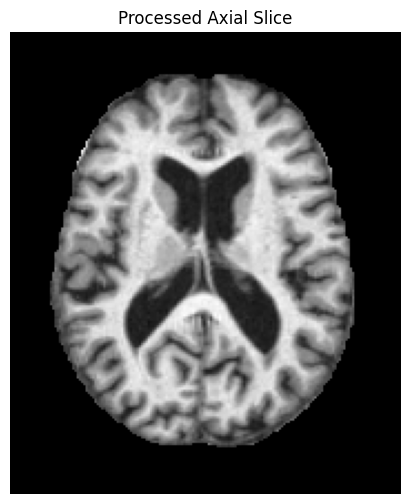

In [4]:
try:
    # Load the 3D volume
    img = nib.load(file_path)
    img_data = np.squeeze(img.get_fdata())

    print(f"3D volume loaded. Shape: {img_data.shape}")

    # Visualize the middle slice of the volume
    middle_slice_idx = img_data.shape[2] // 2
    axial_slice = img_data[:,:,middle_slice_idx]

    plt.figure(figsize=(6, 6))
    plt.imshow(axial_slice.T, cmap='gray', origin='lower')
    plt.title('Processed Axial Slice')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error loading or visualizing the 3D volume: {e}")


In [5]:
excel_path = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data\Demographic and Clinical Data\oasis_cross-sectional-5708aa0a98d82080.xlsx"

try:
    # Load the .csv file into a DataFrame
    clinical_df = pd.read_excel(excel_path)
    print("Clinical data loaded successfully.")

    df_clean = clinical_df.dropna(subset=['CDR']).copy()
    df_clean['CDR'] = df_clean['CDR'].astype(str).str.replace(',', '.').astype(float)
    df_clean['Label'] = (df_clean['CDR'] > 0.0).astype(int)

    print(f"Original patients: {len(clinical_df)}")
    print(f"Patients after cleaning: {len(df_clean)}\n")

    print("--- Final Labels Distribution ---")
    print("0 = Healthy, 1 = Alzheimer's")
    display(df_clean.value_counts())

    display(df_clean.head())

except Exception as e:
    print(f"Error loading the clinical data: {e}")

Clinical data loaded successfully.
Original patients: 436
Patients after cleaning: 235

--- Final Labels Distribution ---
0 = Healthy, 1 = Alzheimer's


Series([], Name: count, dtype: int64)

,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,Label
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,0
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,0
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,1
8,OAS1_0010_MR1,M,R,74,5.0,2.0,30.0,0.0,1636,0.689,1.073,NaN,0
9,OAS1_0011_MR1,F,R,52,3.0,2.0,30.0,0.0,1321,0.827,1.329,NaN,0


In [6]:
base_dir = r"C:\Users\collu\Desktop\alzheimer-xai-prj\data\disc1"

valid_data = []
missing_data = []

for index, row in df_clean.iterrows():
    subject_id = row['ID']
    label = row['Label']

    subject_folder = os.path.join(base_dir, subject_id, "PROCESSED", "MPRAGE", "T88_111")

    if os.path.isdir(subject_folder):
        search_pattern = os.path.join(subject_folder, "*.hdr")
        hdr_files = glob.glob(search_pattern)

        if len(hdr_files) > 0:
            file_path = hdr_files[0]
            valid_data.append({
                'ID': subject_id,
                'Path': file_path,
                'Label': label
            })
        else:
            missing_data.append(subject_id)

    else:
        missing_data.append(subject_id)

dataset_df = pd.DataFrame(valid_data)

print(f"Total clinical patients in CSV: {len(df_clean)}")
print(f"Patients successfully found in Disc 1: {len(dataset_df)}")
print(f"Missing patients (waiting in Discs 2-12): {len(missing_data)}\n")

if len(dataset_df) > 0:
    print("--- Final Machine Learning Dataset ---")
    display(dataset_df.head())

Total clinical patients in CSV: 235
Patients successfully found in Disc 1: 25
Missing patients (waiting in Discs 2-12): 210

--- Final Machine Learning Dataset ---


,ID,Path,Label
0,OAS1_0001_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
1,OAS1_0002_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
2,OAS1_0003_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,1
3,OAS1_0010_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0
4,OAS1_0011_MR1,C:\Users\collu\Desktop\alzheimer-xai-prj\data\...,0


In [7]:
# Save the processed dataframe so other notebooks can use it
os.makedirs('../data/processed', exist_ok=True)
dataset_df.to_csv('../data/processed/dataset_metadata.csv', index=False)

In [8]:
from src.preprocessing import load_and_preprocess_image

try:
    # Get the first patient from our dataset table
    first_patient = dataset_df.iloc[0]
    test_path = first_patient['Path']
    
    print(f"Processing patient: {first_patient['ID']} (Label: {first_patient['Label']})")
    
    # Process the image using our new module
    ready_img = load_and_preprocess_image(test_path)
    
    print(f"Final shape: {ready_img.shape}")
    print(f"Min pixel value: {np.min(ready_img)}")
    print(f"Max pixel value: {np.max(ready_img)}")

except Exception as e:
    print(f"Error during testing: {e}")

Processing patient: OAS1_0001_MR1 (Label: 0)
Final shape: (176, 208, 176)
Min pixel value: 0.0
Max pixel value: 1.0
